In [ ]:
import xarray as xr
import glob as glob
import proplot as plot
import pandas as pd
import numpy as np
import dask
import matplotlib as mpl
from matplotlib import animation, cm
from matplotlib import colorbar, colors
import matplotlib.pyplot as plt
import seaborn as sns


######## Mask the ocean data for plotting: 
mask = xr.open_dataset('p_cal_cesm2_mask.nc')

#######################################################################
### Large SE US Domain ####
lat_r4 = slice(25,43)
lon_r4 = slice(256,291)
loc_r4 = 'Large SE US Domain'
loc_r4_save = 'LD'
#######################################################################


In [ ]:
############### SET THESE VARIABLES: ###############
Xvar_in = 'cape_cin' 
Xvar_name = 'mcape'
X_units = 'J/kg'
X_save = Xvar_name
y_title = 'CAPE'
###########################
Yvar_in ='cape_cin'
Yvar_name = 'mcin'
Y_units = 'J/kg'
Y_save = Yvar_name
Y_title = 'CIN'
###########################
Zvar_in ='S06'
Zvar_name = 'S06'
Z_units = 'm/s'
Z_save = Zvar_name
Z_title = 'S06'
###########################
lat_interest = lat_r4
lon_interest = lon_r4
interest_title = loc_r4
interest_save = loc_r4_save
###########################
climo = '1971-2000'
climo_start = '1971'
climo_end = '2000'

period1 = '2021-2050'
p1_start = '2021'
p1_end = '2050'

period2 = '2051-2070'
p2_start = '2071'
p2_end = '2100'

period3 = '2071-2100'

save_period = '2100'

In [3]:
#################### Always add sorted() on to glob to ensure ensembles are loaded in the proper order!!!
##### Load in datasets:
x_hist = sorted(glob.glob(Xvar_in + '.mamj.LE2.FORCLIMOS.*.1870-2014.nc'))
y_hist = sorted(glob.glob(Yvar_in + '.mamj.LE2.FORCLIMOS.*.1870-2014.nc'))
x_fut = sorted(glob.glob(Xvar_in + '.mamj.LE2.FORCLIMOS.*.2015-2100.nc'))
y_fut = sorted(glob.glob(Yvar_in + '.mamj.LE2.FORCLIMOS.*.2015-2100.nc'))
z_hist = sorted(glob.glob(Zvar_in + '.mamj.LE2.FORCLIMOS.*.1870-2014.nc'))
z_fut = sorted(glob.glob(Zvar_in + '.mamj.LE2.FORCLIMOS.*.2015-2100.nc'))

##### Open datasets:
xVarh = xr.open_mfdataset(x_hist,  concat_dim = 'realization', combine = 'nested').where(mask.LSMASK == 1.0)
yVarh = xr.open_mfdataset(y_hist,  concat_dim = 'realization', combine = 'nested').where(mask.LSMASK == 1.0)*(-1)
xVarf = xr.open_mfdataset(x_fut,  concat_dim = 'realization', combine = 'nested').where(mask.LSMASK == 1.0)
yVarf = xr.open_mfdataset(y_fut,  concat_dim = 'realization', combine = 'nested').where(mask.LSMASK == 1.0)*(-1)
zVarh = xr.open_mfdataset(z_hist,  concat_dim = 'realization', combine = 'nested').where(mask.LSMASK == 1.0)
zVarf = xr.open_mfdataset(z_fut,  concat_dim = 'realization', combine = 'nested').where(mask.LSMASK == 1.0)


### Base Period

In [ ]:
######### (1971-2000) BASE PERIOD 
x_seas_r4 = xVarh.groupby('time.year').mean(dim = 'time').sel(year = slice(climo_start, climo_end)).sel(lat = lat_interest, lon = lon_interest)
y_seas_r4 = yVarh.groupby('time.year').mean(dim = 'time').sel(year = slice(climo_start, climo_end)).sel(lat = lat_interest, lon = lon_interest)
z_seas_r4 = zVarh.groupby('time.year').mean(dim = 'time').sel(year = slice(climo_start, climo_end)).sel(lat = lat_interest, lon = lon_interest)

##### Weight the area average by latitude: 
weights_x = np.cos(np.deg2rad(x_seas_r4.lat))
weights_x.name = "weights"
mamj_weighted_x = x_seas_r4.weighted(weights_x)
x_seas_r4w = mamj_weighted_x.mean(("lon", "lat"))

##### Weight the area average by latitude: 
weights_y = np.cos(np.deg2rad(y_seas_r4.lat))
weights_y.name = "weights"
mamj_weighted_y = y_seas_r4.weighted(weights_y)
y_seas_r4w = mamj_weighted_y.mean(("lon", "lat"))

##### Weight the area average by latitude: 
weights_z = np.cos(np.deg2rad(z_seas_r4.lat))
weights_z.name = "weights"
mamj_weighted_z = z_seas_r4.weighted(weights_z)
z_seas_r4w = mamj_weighted_z.mean(("lon", "lat"))

## Select proper variable from the dataset:
x_r4 = x_seas_r4w[Xvar_name]
y_r4 = y_seas_r4w[Yvar_name]
z_r4 = z_seas_r4w[Zvar_name]

## Concat the ensembles together:
xtest_r4 = xr.concat([x_r4[:, i] for i in range(50)], dim='year')
ytest_r4 = xr.concat([y_r4[:, i] for i in range(50)], dim='year')
ztest_r4 = xr.concat([z_r4[:, i] for i in range(50)], dim='year')

### Create dataframe with both variables of interest: 
base_r4_xset = xr.merge([xtest_r4,ytest_r4])
base_r4_df = base_r4_xset.to_dataframe()                          #### This has 1500 points!
base_r4_30yC = base_r4_xset.groupby('year').mean(dim = 'year')   #### This changes 1500 points to 30 points!
base_r4_30yC_df = base_r4_30yC.to_dataframe()                    #### This has 30 points!

### Create dataframe with both vars of interest: 
base_r4_xsetZ = xr.merge([xtest_r4,ztest_r4])
base_r4_dfZ = base_r4_xsetZ.to_dataframe()
base_r4_30yCZ = base_r4_xsetZ.groupby('year').mean(dim = 'year')
base_r4_30yC_dfZ = base_r4_30yCZ.to_dataframe() 


### Period 1

In [ ]:
######### (1971-2000) BASE PERIOD 
x_seas1_r4 = xVarf.groupby('time.year').mean(dim = 'time').sel(year = slice(p1_start, p1_end)).sel(lat = lat_interest, lon = lon_interest)
y_seas1_r4 = yVarf.groupby('time.year').mean(dim = 'time').sel(year = slice(p1_start, p1_end)).sel(lat = lat_interest, lon = lon_interest)
z_seas1_r4 = zVarf.groupby('time.year').mean(dim = 'time').sel(year = slice(p1_start, p1_end)).sel(lat = lat_interest, lon = lon_interest)

##### Weight the area average by latitude: 
weights_x = np.cos(np.deg2rad(x_seas1_r4.lat))
weights_x.name = "weights"
mamj_weighted_x = x_seas1_r4.weighted(weights_x)
x_seas_r4w = mamj_weighted_x.mean(("lon", "lat"))

##### Weight the area average by latitude: 
weights_y = np.cos(np.deg2rad(y_seas1_r4.lat))
weights_y.name = "weights"
mamj_weighted_y = y_seas1_r4.weighted(weights_y)
y_seas_r4w = mamj_weighted_y.mean(("lon", "lat"))

##### Weight the area average by latitude: 
weights_z = np.cos(np.deg2rad(z_seas1_r4.lat))
weights_z.name = "weights"
mamj_weighted_z = z_seas1_r4.weighted(weights_z)
z_seas_r4w = mamj_weighted_z.mean(("lon", "lat"))

## Select proper variable from the dataset:
x_r4 = x_seas_r4w[Xvar_name]
y_r4 = y_seas_r4w[Yvar_name]
z_r4 = z_seas_r4w[Zvar_name]

## Concat the ensembles together:
xtest1_r4 = xr.concat([x_r4[:, i] for i in range(50)], dim='year')
ytest1_r4 = xr.concat([y_r4[:, i] for i in range(50)], dim='year')
ztest1_r4 = xr.concat([z_r4[:, i] for i in range(50)], dim='year')

### Create dataframe with both variables of interest: 
period1_r4_xset = xr.merge([xtest1_r4,ytest1_r4])
period1_r4_df = period1_r4_xset.to_dataframe()                          #### This has 1500 points!
period1_r4_30yC = period1_r4_xset.groupby('year').mean(dim = 'year')   #### This changes 1500 points to 30 points!
period1_r4_30yC_df = period1_r4_30yC.to_dataframe()                    #### This has 30 points!

### Create dataframe with both vars of interest: 
period1_r4_xsetZ = xr.merge([xtest1_r4,ztest1_r4])
period1_r4_dfZ = period1_r4_xsetZ.to_dataframe()
period1_r4_30yCZ = period1_r4_xsetZ.groupby('year').mean(dim = 'year')
period1_r4_30yC_dfZ = period1_r4_30yCZ.to_dataframe() 


### Period 2

In [ ]:
######### (1971-2000) BASE PERIOD 
x_seas2_r4 = xVarf.groupby('time.year').mean(dim = 'time').sel(year = slice(p2_start, p2_end)).sel(lat = lat_interest, lon = lon_interest)
y_seas2_r4 = yVarf.groupby('time.year').mean(dim = 'time').sel(year = slice(p2_start, p2_end)).sel(lat = lat_interest, lon = lon_interest)
z_seas2_r4 = zVarf.groupby('time.year').mean(dim = 'time').sel(year = slice(p2_start, p2_end)).sel(lat = lat_interest, lon = lon_interest)

##### Weight the area average by latitude: 
weights_x = np.cos(np.deg2rad(x_seas2_r4.lat))
weights_x.name = "weights"
mamj_weighted_x = x_seas2_r4.weighted(weights_x)
x_seas_r4w = mamj_weighted_x.mean(("lon", "lat"))

##### Weight the area average by latitude: 
weights_y = np.cos(np.deg2rad(y_seas2_r4.lat))
weights_y.name = "weights"
mamj_weighted_y = y_seas2_r4.weighted(weights_y)
y_seas_r4w = mamj_weighted_y.mean(("lon", "lat"))

##### Weight the area average by latitude: 
weights_z = np.cos(np.deg2rad(z_seas2_r4.lat))
weights_z.name = "weights"
mamj_weighted_z = z_seas2_r4.weighted(weights_z)
z_seas_r4w = mamj_weighted_z.mean(("lon", "lat"))

## Select proper variable from the dataset:
x_r4 = x_seas_r4w[Xvar_name]
y_r4 = y_seas_r4w[Yvar_name]
z_r4 = z_seas_r4w[Zvar_name]

## Concat the ensembles together:
xtest2_r4 = xr.concat([x_r4[:, i] for i in range(50)], dim='year')
ytest2_r4 = xr.concat([y_r4[:, i] for i in range(50)], dim='year')
ztest2_r4 = xr.concat([z_r4[:, i] for i in range(50)], dim='year')


### Create dataframe with both variables of interest: 
period2_r4_xset = xr.merge([xtest2_r4,ytest2_r4])
period2_r4_df = period2_r4_xset.to_dataframe()                          #### This has 1500 points!
period2_r4_30yC = period2_r4_xset.groupby('year').mean(dim = 'year')   #### This changes 1500 points to 30 points!
period2_r4_30yC_df = period2_r4_30yC.to_dataframe()                    #### This has 30 points!

### Create dataframe with both vars of interest: 
period2_r4_xsetZ = xr.merge([xtest2_r4,ztest2_r4])
period2_r4_dfZ = period2_r4_xsetZ.to_dataframe()
period2_r4_30yCZ = period2_r4_xsetZ.groupby('year').mean(dim = 'year')
period2_r4_30yC_dfZ = period2_r4_30yCZ.to_dataframe() 


# Plotting

### CIN

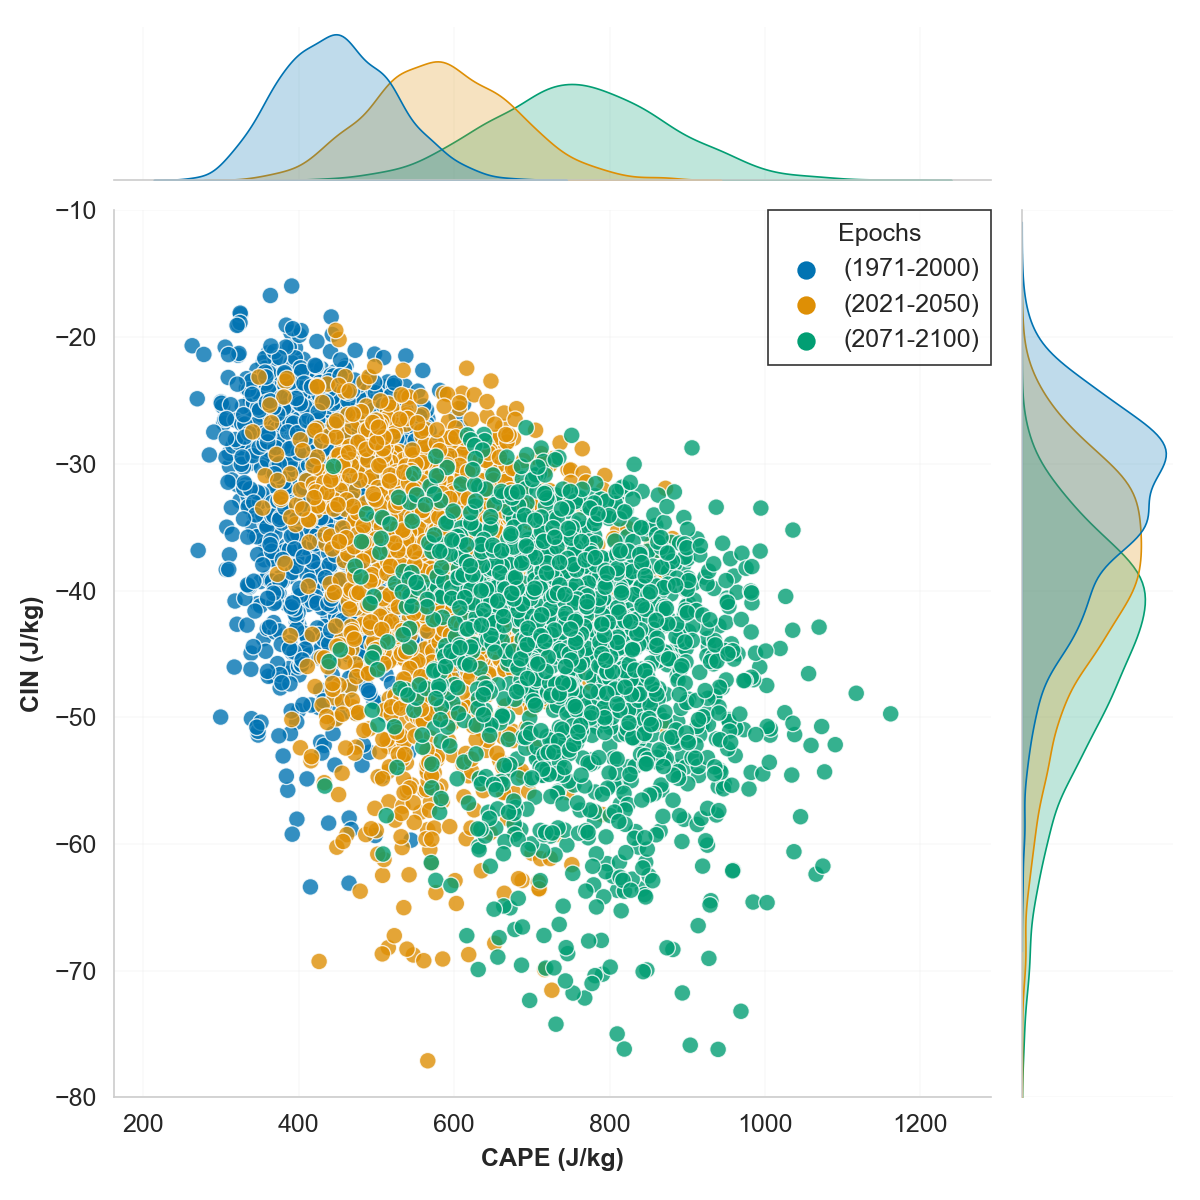

In [ ]:
#### Create a new column in the data frame named 'points' (PeriodOfINTerest), then append all periods to create new data array: 
###### THIS IS FOR 1500 POINTS!!!!!!!!
base_r4_df['Epochs'] = '(' + climo +')'           ### Dataframe
period1_r4_df['Epochs'] = '(' + period1 +')'    ### Dataframe
period2_r4_df['Epochs'] = '(' + period2 +')'    ### Dataframe
dataFrame_r4 = base_r4_df.append([period1_r4_df,period2_r4_df])       ### Dataframe
dist_r4 = dataFrame_r4.to_xarray() 


########################################################################################################################
### kde stands for kernel density estimation....This shows a plot of the periods alone!!! NO DIFFERENCES! 1500 POINTS!!
sns.set_style("whitegrid")
# plt.style.use("dark_background")
g = sns.jointplot(data = dist_r4, x = Xvar_name, y = Yvar_name, hue = 'Epochs' , palette = 'colorblind',    
                  kind = 'scatter', alpha = .8, legend = True, facecolor = 'black');#.plot_joint(sns.scatterplot, color = 'salmon', alpha = .3);
g.ax_joint.set_ylim(-80,-10)
g.ax_joint.set_xlabel(X_title +' ('+ X_units +')', weight = 'bold')
g.ax_joint.set_ylabel(Y_title +' ('+ Y_units +')', weight = 'bold')    

# plt.show()
# plt.savefig('/Users/mfranke/Desktop/JGRReviewEdits/cape_cin_scatterplotDist_version1.jpg', dpi = 500)


### S06

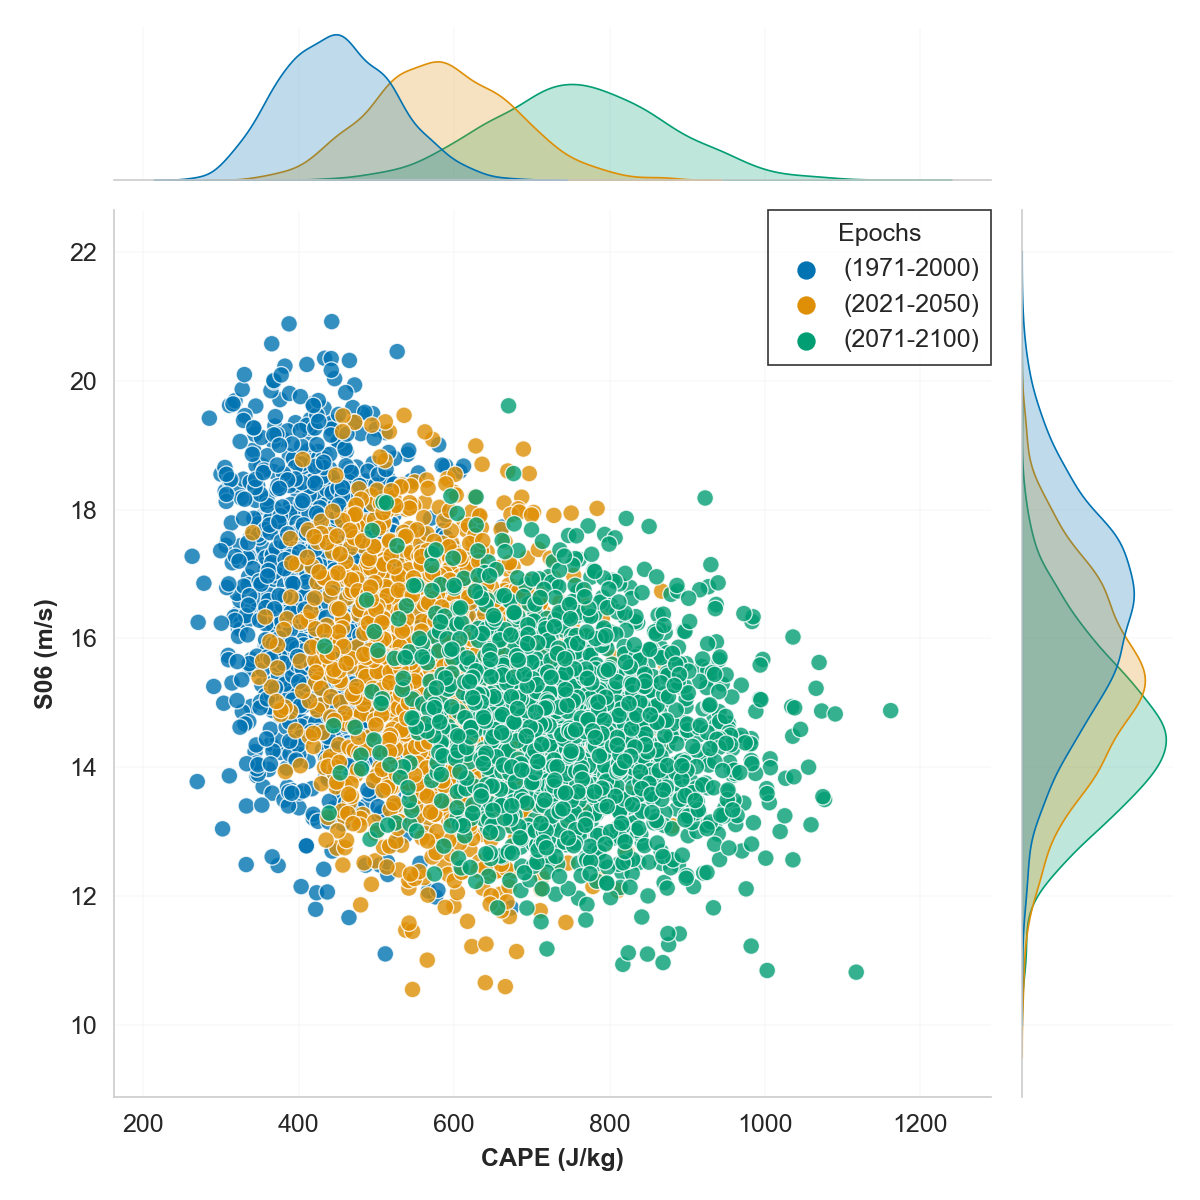

In [ ]:
#### Create a new column in the data frame named 'points' (PeriodOfINTerest), then append all periods to create new data array: 
###### THIS IS FOR 1500 POINTS!!!!!!!!
base_r4_dfZ['Epochs'] = '(' + climo +')'           ### Dataframe
period1_r4_dfZ['Epochs'] = '(' + period1 +')'    ### Dataframe
period2_r4_dfZ['Epochs'] = '(' + period2 +')'    ### Dataframe
dataFrame_r4Z = base_r4_dfZ.append([period1_r4_dfZ,period2_r4_dfZ])       ### Dataframe
dist_r4Z = dataFrame_r4Z.to_xarray() 


########################################################################################################################
### kde stands for kernel density estimation....This shows a plot of the periods alone!!! NO DIFFERENCES! 1500 POINTS!!
sns.set_style("whitegrid")
# plt.style.use("dark_background")
g = sns.jointplot(data = dist_r4Z, x = Xvar_name, y = Zvar_name, hue = 'Epochs' , palette = 'colorblind',   
                  kind = 'scatter', alpha = .8,  legend = True, facecolor = 'black')#.plot_joint(sns.scatterplot, color = 'salmon', alpha = .3);
g.ax_joint.set_xlabel(X_title +' ('+ X_units +')', weight = 'bold')
g.ax_joint.set_ylabel(Z_title +' ('+ Z_units +')', weight = 'bold')    ### Change to Z or Y

# plt.show()
# plt.savefig('/Users/mfranke/Desktop/JGRReviewEdits/cape_s06_scatterplotDist_version1.jpg', dpi = 500)
